In [ ]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('img_umb.jpg') # lee en escala de grises
#umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
# umbralizacion binaria inversa
_,umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binario, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binario_inv, cmap='gray')

plt.show()

In [ ]:
## Practica

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = '../clase2/kermit.jpg'
imagen_bgr = cv2.imread(ruta, cv2.IMREAD_COLOR)

if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo cargar la imagen: {ruta}')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

versiones_bayer = [
    'COLOR_BayerRG2RGB',
    'COLOR_BayerBG2RGB',
    'COLOR_BayerGB2RGB',
    'COLOR_BayerGR2RGB',
    'COLOR_BayerRG2RGB_VNG',
    'COLOR_BayerRG2RGB_EA',
]

print('Imagen seleccionada:', ruta)
print('Versiones Bayer que se usaran en la practica:')
for nombre in versiones_bayer:
    print(nombre)

Imagen seleccionada: ../clase2/kermit.jpg
Versiones Bayer que se usaran en la practica:
COLOR_BayerRG2RGB
COLOR_BayerBG2RGB
COLOR_BayerGB2RGB
COLOR_BayerGR2RGB
COLOR_BayerRG2RGB_VNG
COLOR_BayerRG2RGB_EA


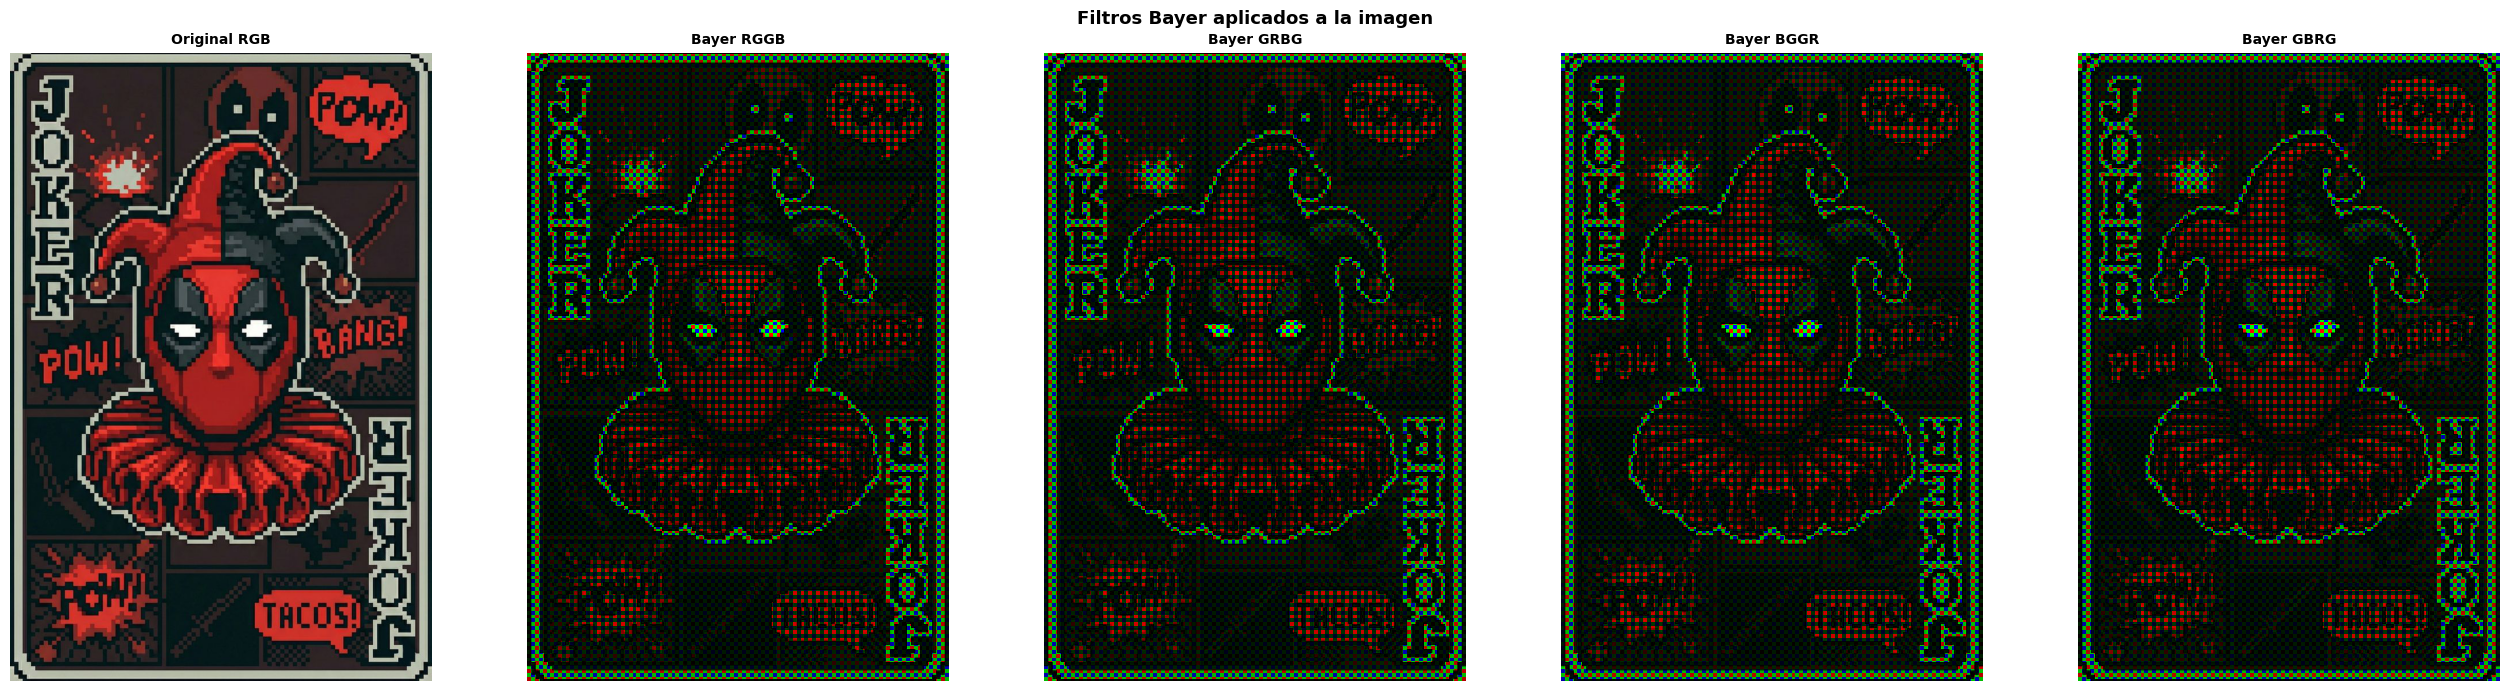

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = '../clase2/deadpool.jpg'
img_bgr = cv2.imread(ruta)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]
canales = cv2.split(img_rgb)

def aplicar_patron(canales_img, nombre_patron):
    r, g, b = canales_img
    resultado = np.zeros((h, w, 3), dtype=np.uint8)
    
    patrones = {
        'RGGB': {r: (0, 0), g: [(0, 1), (1, 0)], b: (1, 1)},
        'GRBG': {g: [(0, 0), (1, 1)], r: (0, 1), b: (1, 0)},
        'BGGR': {b: (0, 0), g: [(0, 1), (1, 0)], r: (1, 1)},
        'GBRG': {g: [(0, 0), (1, 1)], b: (0, 1), r: (1, 0)}
    }
    
    config = patrones[nombre_patron]
    for canal, posiciones in config.items():
        if isinstance(posiciones, tuple):
            row, col = posiciones
            resultado[row::2, col::2, [0, 1, 2][cv2.cvtColor(np.uint8([[[canal[0], canal[1], canal[2]]]]), cv2.COLOR_RGB2HSV).any()]] = canal[row::2, col::2]
        else:
            for row, col in posiciones:
                resultado[row::2, col::2, 1] = canal[row::2, col::2]
    
    return resultado

def crear_bayer(img, patron):
    h, w = img.shape[:2]
    salida = np.zeros((h, w, 3), dtype=np.uint8)
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    
    if patron == 'RGGB':
        salida[0::2, 0::2, 0] = r[0::2, 0::2]
        salida[0::2, 1::2, 1] = g[0::2, 1::2]
        salida[1::2, 0::2, 1] = g[1::2, 0::2]
        salida[1::2, 1::2, 2] = b[1::2, 1::2]
    elif patron == 'GRBG':
        salida[0::2, 0::2, 1] = g[0::2, 0::2]
        salida[0::2, 1::2, 0] = r[0::2, 1::2]
        salida[1::2, 0::2, 2] = b[1::2, 0::2]
        salida[1::2, 1::2, 1] = g[1::2, 1::2]
    elif patron == 'BGGR':
        salida[0::2, 0::2, 2] = b[0::2, 0::2]
        salida[0::2, 1::2, 1] = g[0::2, 1::2]
        salida[1::2, 0::2, 1] = g[1::2, 0::2]
        salida[1::2, 1::2, 0] = r[1::2, 1::2]
    elif patron == 'GBRG':
        salida[0::2, 0::2, 1] = g[0::2, 0::2]
        salida[0::2, 1::2, 2] = b[0::2, 1::2]
        salida[1::2, 0::2, 0] = r[1::2, 0::2]
        salida[1::2, 1::2, 1] = g[1::2, 1::2]
    
    return salida

nombres = ['RGGB', 'GRBG', 'BGGR', 'GBRG']
tabla_datos = [(pat, crear_bayer(img_rgb, pat)) for pat in nombres]


fig, axes = plt.subplots(1, 5, figsize=(26, 7))
fig.suptitle('Filtros Bayer aplicados a la imagen', fontsize=13, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB', fontsize=10, fontweight='bold')
axes[0].axis('off')

for i, (nombre, datos) in enumerate(tabla_datos, 1):
    axes[i].imshow(datos, interpolation='nearest')
    axes[i].set_title(f'Bayer {nombre}', fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

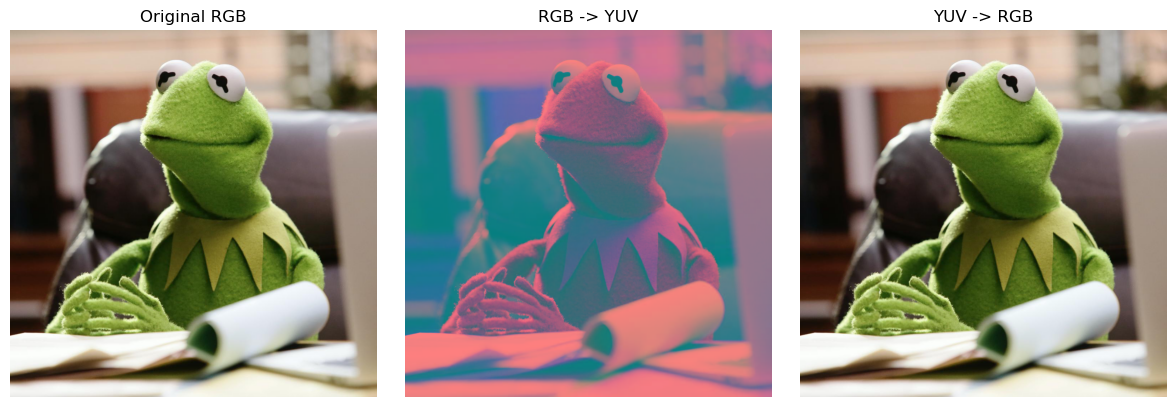

MAE RGB -> YUV -> RGB: 0.2954


In [9]:
rgb = imagen_rgb.copy()

yuv = cv2.cvtColor(rgb, cv2.COLOR_RGB2YUV)
rgb_recuperada = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(yuv)
plt.title('RGB -> YUV')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rgb_recuperada)
plt.title('YUV -> RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

mae = np.mean(np.abs(rgb.astype(np.int16) - rgb_recuperada.astype(np.int16)))
print(f'MAE RGB -> YUV -> RGB: {mae:.4f}')

Trabajo 18/03   umbralizacion GLOBAL,  ISODATA

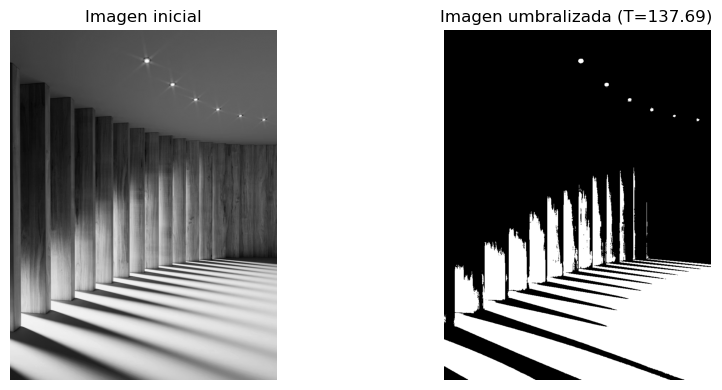

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(image):
    umbral = 128
    while True:
        grupo1 = image[image <= umbral]  # grupo donde el umbral es menor o igual
        grupo2 = image[image > umbral]   # grupo donde el umbral es mayor

        media1 = np.mean(grupo1) if grupo1.size > 0 else 0
        media2 = np.mean(grupo2) if grupo2.size > 0 else 0

        nuevo_umbral = (media1 + media2) / 2  # nuevo umbral promedio de medias

        if abs(umbral - nuevo_umbral) < 0.5:
            break
        umbral = nuevo_umbral
    return umbral

imagen = cv2.imread('imagenumbra.jpeg', 0)
if imagen is None:
    raise FileNotFoundError('No hay imagen papito')

umbral_isodata = isodata(imagen)
_, imagen_umbralizada = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title(f'Imagen umbralizada (T={umbral_isodata:.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

globales 


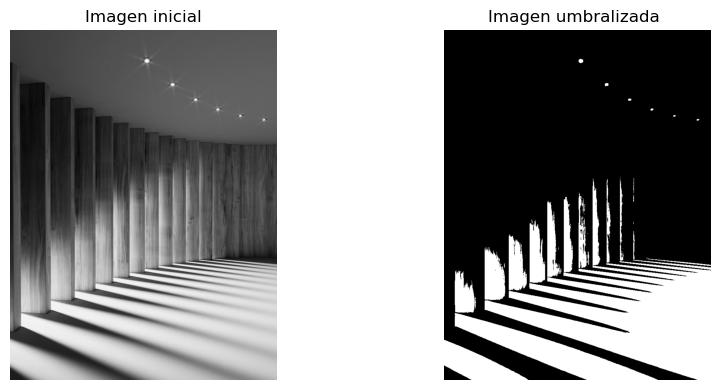

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]) #hago uso de histograma
    #seleccionamos los 2 picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico) #diferencia entre los tipos
    primer_pico=np.argmax(pico_dif[:128]) #primer pico
    segundo_pico=np.argmax(pico_dif[128:])+128 #segundo pico

    umbral= int((primer_pico + segundo_pico) / 2) #umbral entre los 2 picos
    return umbral

imagen=cv2.imread('imagenumbra.jpeg', 0)
umbral_2_picos=dos_picos(imagen)

_, nueva = cv2.threshold(imagen, umbral_2_picos, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(nueva, cmap='gray')
plt.title(f'Imagen umbralizada ')
plt.axis('off')

plt.tight_layout()
plt.show()

metodo otsu


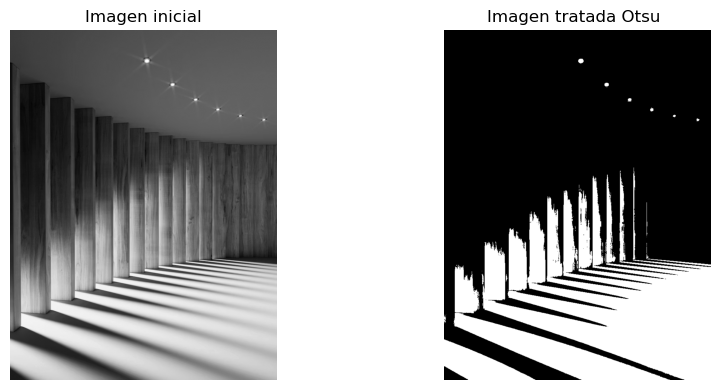

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('imagenumbra.jpeg', 0)
umbral_otsu, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imagen_fin = np.where(image > umbral_otsu, 255, 0).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title(f'Imagen tratada Otsu ')
plt.axis('off')

plt.tight_layout()
plt.show()

umbralizacion variable particion de una imagen

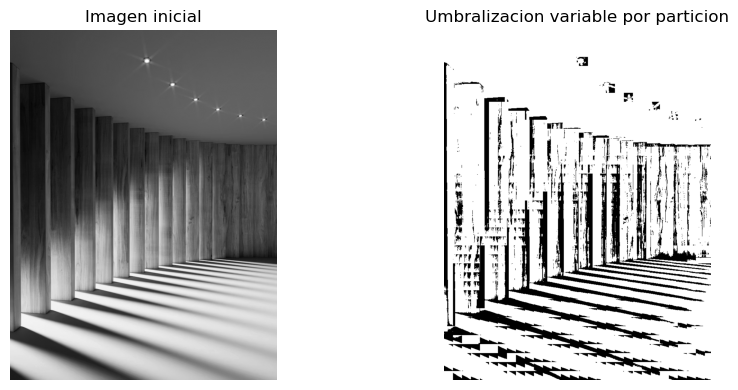

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image, tam_bloque, c):
    umbral_img = np.zeros_like(image)
    for y in range(0, image.shape[0], tam_bloque):
        for x in range(0, image.shape[1], tam_bloque):
            bloque = image[y:y+tam_bloque, x:x+tam_bloque]
            bloq_media = np.mean(bloque)
            umbral = bloq_media - c
            umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral).astype(np.uint8) * 255
    return umbral_img

tam_b = 25
c = 10
image = cv2.imread('imagenumbra.jpeg', 0)
img_fin = variable_part(image, tam_b, c)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralizacion variable por particion')
plt.axis('off')

plt.tight_layout()
plt.show()

propiedades locales

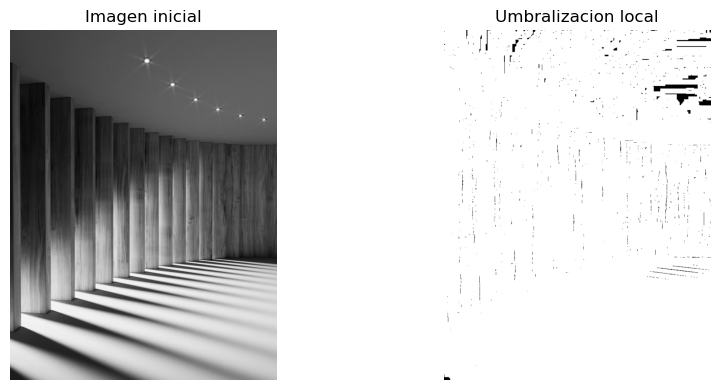

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('imagenumbra.jpeg', 0)
def local(image, tamanio_ventana, k):
    umbr_img=np.zeros_like(image)
    pad= tamanio_ventana//2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)

            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tamanio_ventana=15
k=2
img_fin=local(image, tamanio_ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralizacion local')
plt.axis('off')

plt.tight_layout()
plt.show()

variable con open cv

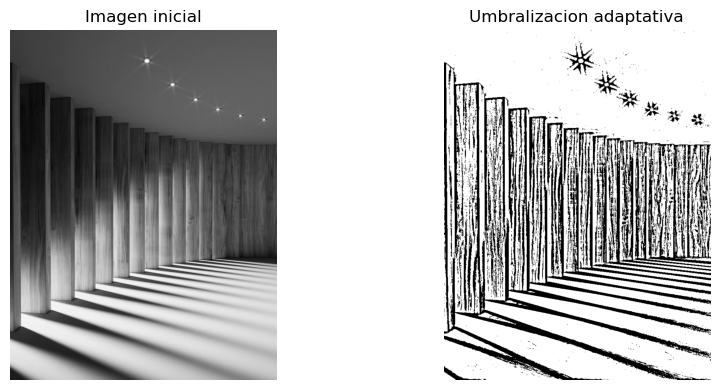

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('imagenumbra.jpeg', 0)

ventana = 15
k = 2
imagen_fin = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralizacion adaptativa')
plt.axis('off')

plt.tight_layout()
plt.show()

otsu

Umbral Otsu manual identificado: 137
Umbral Otsu de OpenCV: 137


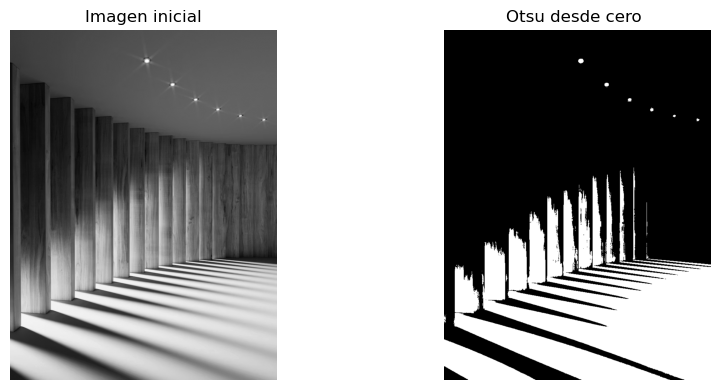

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagenumbra.jpeg', 0)

hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
p = hist / hist.sum()

w0 = 0.0
mu0_acum = 0.0
mu_total = np.sum(np.arange(256) * p)
#formulita
mejor_t = 0
max_sigma_b = -1.0

for t in range(256):
    w0 += p[t]
    mu0_acum += t * p[t]
    w1 = 1.0 - w0

    if w0 == 0 or w1 == 0:
        continue

    mu0 = mu0_acum / w0
    mu1 = (mu_total - mu0_acum) / w1
    sigma_b = w0 * w1 * (mu0 - mu1) ** 2

    if sigma_b > max_sigma_b:
        max_sigma_b = sigma_b
        mejor_t = t

img_otsu_manual = np.where(img > mejor_t, 255, 0).astype(np.uint8)

t_cv, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Umbral Otsu manual identificado: {mejor_t}')
print(f'Umbral Otsu de OpenCV: {int(t_cv)}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_otsu_manual, cmap='gray')
plt.title(f'Otsu desde cero ')
plt.axis('off')

plt.tight_layout()
plt.show()